# Course 2: Advanced Architectures for Computer Vision

## Complete Summary with Theory, Math, and Practice

This notebook covers two powerful paradigms: **Transfer Learning** — leveraging pre-trained models for new tasks — and **Autoencoders** — unsupervised representation learning for compression, anomaly detection, and denoising.

---

## Table of Contents
1. [Transfer Learning: The Paradigm](#transfer-learning)
2. [Implementation Strategies](#implementation-strategies)
3. [Practical Considerations and Domain Shift](#practical)
4. [Case Study: End-to-End Transfer Learning](#case-study)
5. [Autoencoders: Framework and Applications](#autoencoders)
6. [Architectural Variations of Autoencoders](#ae-variants)
7. [Practical Implementation: Latent Space Visualization](#ae-impl)

---

<a name="transfer-learning"></a>
## 1. Transfer Learning: Standing on the Shoulders of Giants

### The Core Idea

Pre-train a network on a **large, general dataset** (e.g. ImageNet — 1.2M images, 1,000 classes), then **adapt** it to a specific downstream task.

$$\underbrace{\theta_{\text{pretrained}}}_{\text{ImageNet}} \xrightarrow{\text{adapt}} \underbrace{\theta_{\text{fine-tuned}}}_{\text{your task}}$$

### Why Training from Scratch Is Rarely Optimal

| Scenario | Training from Scratch | Transfer Learning |
|----------|----------------------|-------------------|
| 100K labelled images | ✅ Feasible (maybe) | ✅ Better result |
| 10K labelled images | ⚠️ Likely overfit | ✅ Strong baseline |
| <1K labelled images | ❌ Severe overfit | ✅ Only viable path |
| Infinite compute | ✅ Fine | Wasteful without reason |

### What Gets Transferred?

Early CNN layers capture **universal** low-level features (edges, textures, colour gradients) that transfer broadly across visual domains. Later layers are **task-specific**.

```
Layer hierarchy:
[Layer 1-3]  Edges, blobs, colours  ──── transfer well to most tasks
[Layer 4-6]  Textures, patterns     ──── transfer well within domain
[Layer 7+]   Object parts/semantics ──── task-specific, often replaced
[Final FC]   Class scores           ──── always replaced
```

### Knowledge Transfer Across Domains

The closer the **source** and **target** domains:

| Distance | Strategy |
|----------|---------|
| Same domain (e.g. cats → dogs) | Fine-tune few/no layers |
| Related domain (medical → natural images) | Fine-tune more layers |
| Very different domain (ImageNet → satellite) | Fine-tune most layers |

<a name="implementation-strategies"></a>
## 2. Implementation Strategies

### Strategy 1: Feature Extraction (Frozen Backbone)

Freeze **all** pre-trained weights; only train the new classifier head.

```python
for param in backbone.parameters():
    param.requires_grad = False      # freeze
# Only new_head parameters are trained
```

**When to use:** Small dataset, high similarity to source domain.

### Strategy 2: Fine-Tuning (Unfrozen Layers)

Unfreeze some or all layers and train with a **very small learning rate**.

$$\alpha_{\text{backbone}} \ll \alpha_{\text{head}}$$

Typical split: use $10\times$ to $100\times$ lower LR for pre-trained layers.

**When to use:** Medium dataset, any domain.

### Strategy 3: Progressive Unfreezing

Unfreeze layers **gradually** from top (task-specific) to bottom (general):

```
Epoch 1-3:   Train head only
Epoch 4-6:   Unfreeze top 2 blocks + head
Epoch 7-9:   Unfreeze all layers
```

This prevents **catastrophic forgetting** — the destruction of learned features by large early gradient updates.

### Decision Framework

```
Dataset size?
├── Large (>100K):  Fine-tune everything, small LR
├── Medium (10K):   Progressive unfreeze
└── Small (<5K):
        Domain similar to source?
        ├── Yes: Feature extraction only  
        └── No:  Feature extraction + augmentation
```

### Differential Learning Rates

Using parameter groups in PyTorch (example-style pseudocode):

```python
optimizer = Adam([
    {"params": backbone.layer1.parameters(), "lr": 1e-5},
    {"params": backbone.layer2.parameters(), "lr": 1e-4},
    {"params": head.parameters(),            "lr": 1e-3},
])
```

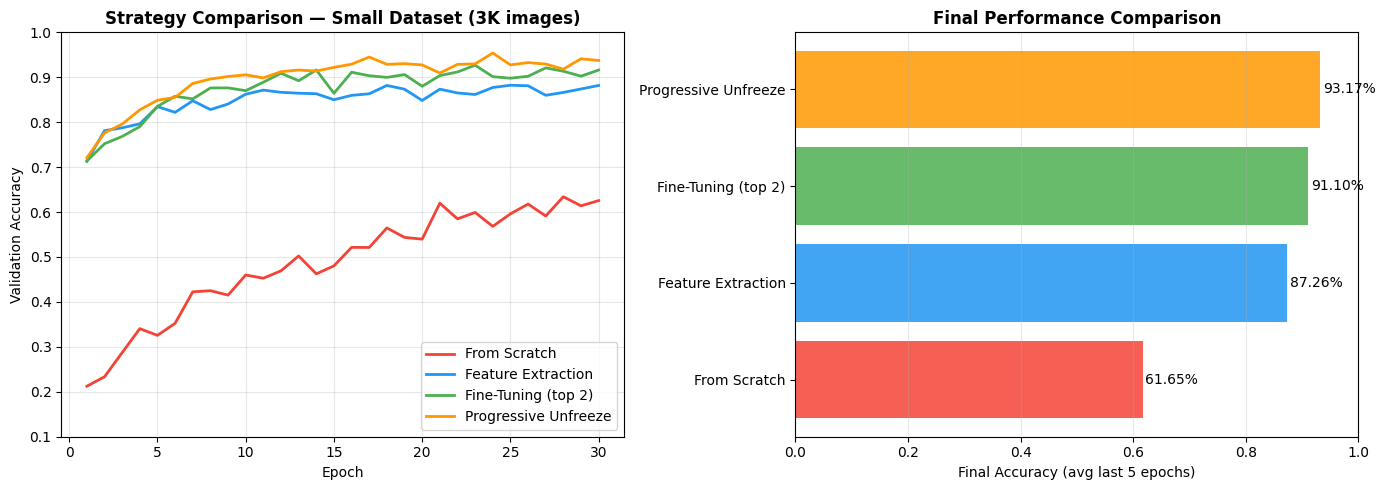

Trainable parameters by strategy (ResNet-50 backbone, 5-class head):

  Feature Extraction            trainable:     10,245  (0.0%)
  Fine-Tune top 3 layers        trainable:  3,370,053  (14.3%)
  Full Fine-Tuning              trainable: 23,518,277  (100.0%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Simulating Feature Extraction vs Fine-tuning learning curves ──────────────
np.random.seed(42)

def simulate_training(n_epochs, start_acc, plateau_acc, noise=0.015, speed=0.15):
    """Simulate a learning curve with logistic growth + noise."""
    t = np.arange(n_epochs)
    curve = start_acc + (plateau_acc - start_acc) * (1 - np.exp(-speed * t))
    curve += np.random.randn(n_epochs) * noise
    return np.clip(curve, 0, 1)

epochs = np.arange(1, 31)

# Different strategies on a small dataset (3,000 images, 5 classes)
strategies = {
    "From Scratch":          simulate_training(30, 0.20, 0.68, noise=0.025, speed=0.08),
    "Feature Extraction":    simulate_training(30, 0.72, 0.87, noise=0.012, speed=0.30),
    "Fine-Tuning (top 2)":   simulate_training(30, 0.72, 0.91, noise=0.013, speed=0.20),
    "Progressive Unfreeze":  simulate_training(30, 0.72, 0.93, noise=0.010, speed=0.25),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#F44336", "#2196F3", "#4CAF50", "#FF9800"]

# Train accuracy
for (name, curve), color in zip(strategies.items(), colors):
    axes[0].plot(epochs, curve, label=name, color=color, linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("Strategy Comparison — Small Dataset (3K images)", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.1, 1.0)

# Final accuracy bar comparison
final_accs = {name: curve[-5:].mean() for name, curve in strategies.items()}
bars = axes[1].barh(list(final_accs.keys()), list(final_accs.values()),
                     color=colors, alpha=0.85)
axes[1].set_xlabel("Final Accuracy (avg last 5 epochs)")
axes[1].set_title("Final Performance Comparison", fontweight="bold")
axes[1].set_xlim(0, 1.0)
for bar, val in zip(bars, final_accs.values()):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.2%}', va='center', fontsize=10)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()

# ── Parameter count comparison ────────────────────────────────────────────────
print("Trainable parameters by strategy (ResNet-50 backbone, 5-class head):")
print()
configs = {
    "Feature Extraction":   {"frozen": 23_508_032, "trainable": 10_245},
    "Fine-Tune top 3 layers":{"frozen": 20_148_224, "trainable": 3_370_053},
    "Full Fine-Tuning":     {"frozen": 0, "trainable": 23_518_277},
}
for strategy, counts in configs.items():
    total = counts["frozen"] + counts["trainable"]
    pct = counts["trainable"] / total * 100
    print(f"  {strategy:28s}  trainable: {counts['trainable']:>10,}  ({pct:.1f}%)")

<a name="practical"></a>
## 3. Practical Considerations

### Handling Domain Shift

**Domain shift** occurs when pre-trained feature distributions differ from your target domain.

| Source | Target | Shift Level | Mitigation |
|--------|--------|-------------|------------|
| ImageNet (photos) | Medical CT scans | High | Fine-tune all layers, domain adaptation |
| ImageNet (photos) | Product photos | Low | Feature extraction works well |
| ImageNet (photos) | Satellite imagery | High | Fine-tune + data augmentation |

**Domain Adaptation** techniques:
- **Adversarial domain adaptation**: train feature extractor to fool a domain classifier
- **Batch normalization adaptation**: update BN statistics on target domain  
- **Self-supervised pre-training** on unlabelled target data first

### Catastrophic Forgetting

When fine-tuning, large gradient updates can **overwrite** learned general features.

**Solutions:**
1. **Small learning rate** for pre-trained layers ($\sim 10^{-5}$)
2. **Progressive unfreezing** (unfreeze top-to-bottom, one stage at a time)
3. **Elastic Weight Consolidation (EWC)**: penalize changes to important weights:
   $$\mathcal{L}_{\text{EWC}} = \mathcal{L}_{\text{task}} + \frac{\lambda}{2} \sum_i F_i (\theta_i - \theta_i^*)^2$$
   where $F_i$ is the Fisher information matrix diagonal (importance of parameter $i$).

### Computational Trade-offs

| Approach | GPU Memory | Training Time | Inference Time |
|---------|-----------|--------------|----------------|
| Feature Extraction | Low (frozen activations cacheable) | Fast | Same |
| Fine-Tuning | High (full backprop) | Slow | Same |
| Knowledge Distillation | Medium | Medium | Faster (smaller model) |

<a name="autoencoders"></a>
## 5. Autoencoders: Learning to Represent

### The Encoder-Decoder Framework

An autoencoder learns a **compressed representation** by training to reconstruct its own input:

$$\mathbf{x} \xrightarrow{\text{encoder } f_\phi} \mathbf{z} \xrightarrow{\text{decoder } g_\theta} \hat{\mathbf{x}}$$

Where $\mathbf{z} \in \mathbb{R}^d$ is the **latent code** with $d \ll \dim(\mathbf{x})$ (the bottleneck).

**Training objective — Reconstruction loss:**

For images (pixel values in $[0,1]$):
$$\mathcal{L} = \frac{1}{m} \sum_{i=1}^m \|\mathbf{x}^{(i)} - \hat{\mathbf{x}}^{(i)}\|^2 \quad \text{(MSE)}$$

Or binary cross-entropy for sigmoid outputs:
$$\mathcal{L} = -\frac{1}{n} \sum_j [x_j \log \hat{x}_j + (1-x_j) \log(1-\hat{x}_j)]$$

### The Bottleneck Forces Meaningful Compression

```
784 → 256 → 128 → [BOTTLENECK: 32] → 128 → 256 → 784
       encoder              z              decoder
```

The network **cannot just copy** the input — it must learn the most informative compression.

### Core Applications

| Application | How Autoencoder Helps |
|-------------|----------------------|
| **Dimensionality Reduction** | Non-linear generalization of PCA |
| **Feature Learning** | Encoder as unsupervised feature extractor |
| **Anomaly Detection** | Normal samples reconstruct well; anomalies don't |
| **Denoising** | Learn to reconstruct clean from corrupted input |
| **Data Compression** | Encode → store $\mathbf{z}$ → decode when needed |
| **Image generation** | Sample $\mathbf{z}$ from latent space → decode |

### Autoencoder vs PCA

| | PCA | Autoencoder |
|--|-----|-------------|
| Transformation | Linear | Non-linear (with activations) |
| Optimal solution | Closed-form | Iterative (gradient descent) |
| Capacity | Limited to linear subspaces | Can model complex manifolds |
| Interpretability | Principal components | Latent dimensions |

<a name="ae-variants"></a>
## 6. Architectural Variations of Autoencoders

### Undercomplete Autoencoder (Classic)

The simplest form: bottleneck dimension < input dimension.

```
Input (784) → [256 → 128 → 64] → 32 → [64 → 128 → 256] → Output (784)
              └─── encoder ───┘   z   └──── decoder ────┘
```

Risk: if decoder is very powerful, it may memorize without meaningful compression.

### Denoising Autoencoder (DAE)

Train to reconstruct **clean** $\mathbf{x}$ from **corrupted** $\tilde{\mathbf{x}}$:

$$\tilde{\mathbf{x}} = \mathbf{x} + \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(0, \sigma^2 I)$$
$$\mathcal{L} = \|\mathbf{x} - g_\theta(f_\phi(\tilde{\mathbf{x}}))\|^2$$

Forces the model to learn **robust** features that capture true data structure, not noise.

### Sparse Autoencoder

Add a penalty on latent activations to encourage **sparsity**:

$$\mathcal{L} = \mathcal{L}_{\text{recon}} + \lambda \sum_j |z_j|$$

Or use KL divergence from a target sparsity $\rho$:
$$\Omega(\mathbf{z}) = \sum_j \mathrm{KL}(\rho \| \hat{\rho}_j) = \rho \log \frac{\rho}{\hat{\rho}_j} + (1-\rho) \log \frac{1-\rho}{1-\hat{\rho}_j}$$

Where $\hat{\rho}_j$ is the average activation of unit $j$ across the training set.

### Contractive Autoencoder (CAE)

Add a **Frobenius norm penalty** on the encoder Jacobian to make learned representations robust to small input perturbations:

$$\mathcal{L} = \mathcal{L}_{\text{recon}} + \lambda \left\| \frac{\partial f_\phi(\mathbf{x})}{\partial \mathbf{x}} \right\|_F^2$$

### Comparison Table

| Variant | Extra Constraint | Benefit |
|---------|-----------------|---------|
| **Undercomplete** | Bottleneck dimension | Compact representation |
| **Denoising** | Corrupt input during training | Robust, generalisable features |
| **Sparse** | Penalty on $\|\mathbf{z}\|_1$ | Interpretable, disentangled features |
| **Contractive** | Jacobian penalty | Invariant to small perturbations |
| **Variational (VAE)** | $\mathbf{z} \sim \mathcal{N}(\mu, \sigma^2)$ | Generative, smooth latent space |

<a name="ae-impl"></a>
## 7. Practical Implementation: Autoencoders from Scratch

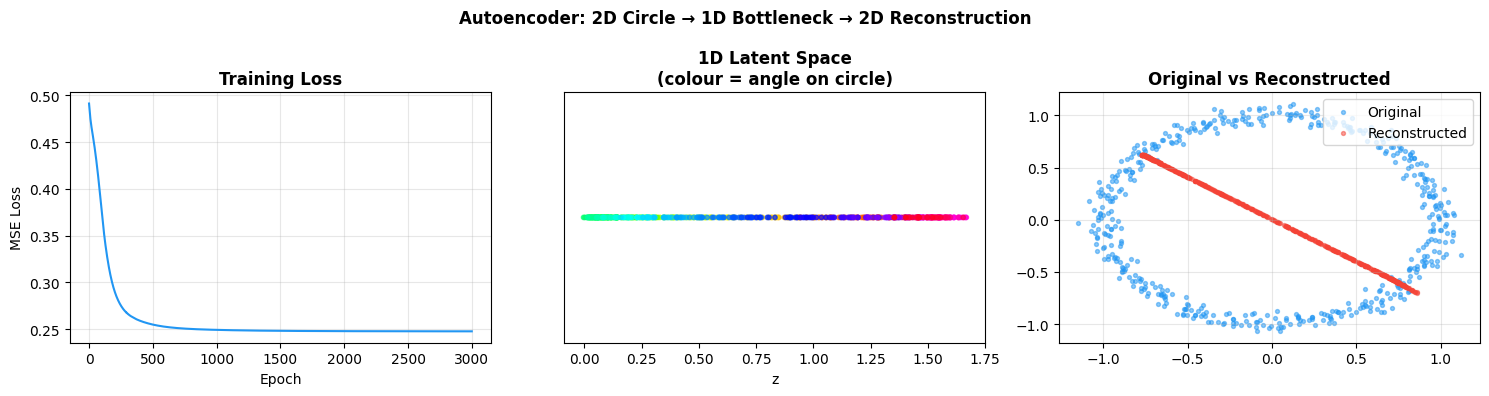

Anomaly Detection via Reconstruction Error:
  Normal samples  — mean error: 0.4952
  Anomalies       — mean error: 1.2526
  Ratio           : 2.5×


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Autoencoder on synthetic 2D data ──────────────────────────────────────────
# We'll simulate a 2D swiss-roll-like dataset and compress to 1D with an AE

np.random.seed(42)

# Generate data: points on a noisy circle (manifold in 2D)
t = np.linspace(0, 2*np.pi, 500)
X = np.stack([np.cos(t) + np.random.randn(500)*0.05,
               np.sin(t) + np.random.randn(500)*0.05], axis=1)  # (500, 2)

def relu(z): return np.maximum(0, z)
def relu_back(z): return (z > 0).astype(float)
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Network: 2 → 4 → 1 → 4 → 2
np.random.seed(0)
We1 = np.random.randn(4, 2) * 0.5; be1 = np.zeros((4, 1))
We2 = np.random.randn(1, 4) * 0.5; be2 = np.zeros((1, 1))
Wd1 = np.random.randn(4, 1) * 0.5; bd1 = np.zeros((4, 1))
Wd2 = np.random.randn(2, 4) * 0.5; bd2 = np.zeros((2, 1))

lr = 0.01
losses = []

for epoch in range(3000):
    # ── Forward ──────────────────────────────────────────────────────────────
    xT = X.T                            # (2, 500)
    Z_e1 = We1 @ xT + be1              # (4, 500)
    A_e1 = relu(Z_e1)
    Z_e2 = We2 @ A_e1 + be2            # (1, 500) ← latent code z
    z    = Z_e2                         # no activation on bottleneck

    Z_d1 = Wd1 @ z + bd1               # (4, 500)
    A_d1 = relu(Z_d1)
    Z_d2 = Wd2 @ A_d1 + bd2            # (2, 500) ← reconstruction
    x_hat = Z_d2

    loss = ((x_hat - xT) ** 2).mean()
    losses.append(loss)

    # ── Backward ──────────────────────────────────────────────────────────────
    m = X.shape[0]
    dZ_d2 = 2 * (x_hat - xT) / m       # MSE grad
    dWd2 = dZ_d2 @ A_d1.T
    dbd2 = dZ_d2.sum(axis=1, keepdims=True)
    dA_d1 = Wd2.T @ dZ_d2
    dZ_d1 = dA_d1 * relu_back(Z_d1)
    dWd1 = dZ_d1 @ z.T
    dbd1 = dZ_d1.sum(axis=1, keepdims=True)

    dz   = Wd1.T @ dZ_d1
    dWe2 = dz @ A_e1.T
    dbe2 = dz.sum(axis=1, keepdims=True)
    dA_e1 = We2.T @ dz
    dZ_e1 = dA_e1 * relu_back(Z_e1)
    dWe1 = dZ_e1 @ xT.T
    dbe1 = dZ_e1.sum(axis=1, keepdims=True)

    # ── Update ────────────────────────────────────────────────────────────────
    for W, dW in [(We1,dWe1),(We2,dWe2),(Wd1,dWd1),(Wd2,dWd2)]:
        W -= lr * dW
    for b, db in [(be1,dbe1),(be2,dbe2),(bd1,dbd1),(bd2,dbd2)]:
        b -= lr * db

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(losses, color="#2196F3", linewidth=1.5)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Loss", fontweight="bold"); axes[0].grid(alpha=0.3)

# Latent representation (1D)
Z_e1_f = relu(We1 @ X.T + be1)
z_final = (We2 @ Z_e1_f + be2).squeeze()
axes[1].scatter(z_final, np.zeros_like(z_final), c=t, cmap="hsv", s=10, alpha=0.7)
axes[1].set_title("1D Latent Space\n(colour = angle on circle)", fontweight="bold")
axes[1].set_xlabel("z"); axes[1].set_yticks([])

# Original vs Reconstruction
A_d1_f = relu(Wd1 @ (We2 @ Z_e1_f + be2) + bd1)
x_hat_f = (Wd2 @ A_d1_f + bd2).T
axes[2].scatter(X[:,0], X[:,1], s=8, label="Original", alpha=0.5, color="#2196F3")
axes[2].scatter(x_hat_f[:,0], x_hat_f[:,1], s=8, label="Reconstructed", alpha=0.5, color="#F44336")
axes[2].set_title("Original vs Reconstructed", fontweight="bold")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("Autoencoder: 2D Circle → 1D Bottleneck → 2D Reconstruction", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Anomaly Detection ──────────────────────────────────────────────────────────
# Points on the circle reconstruct well; points far from the manifold don't
anomalies = np.random.uniform(-2, 2, (30, 2))  # random off-manifold points
Z_a = relu(We1 @ anomalies.T + be1)
z_a = We2 @ Z_a + be2
A_da = relu(Wd1 @ z_a + bd1)
x_hat_a = (Wd2 @ A_da + bd2).T

recon_err_normal   = ((X - x_hat_f)**2).sum(axis=1)
recon_err_anomaly  = ((anomalies - x_hat_a)**2).sum(axis=1)

print("Anomaly Detection via Reconstruction Error:")
print(f"  Normal samples  — mean error: {recon_err_normal.mean():.4f}")
print(f"  Anomalies       — mean error: {recon_err_anomaly.mean():.4f}")
print(f"  Ratio           : {recon_err_anomaly.mean() / recon_err_normal.mean():.1f}×")

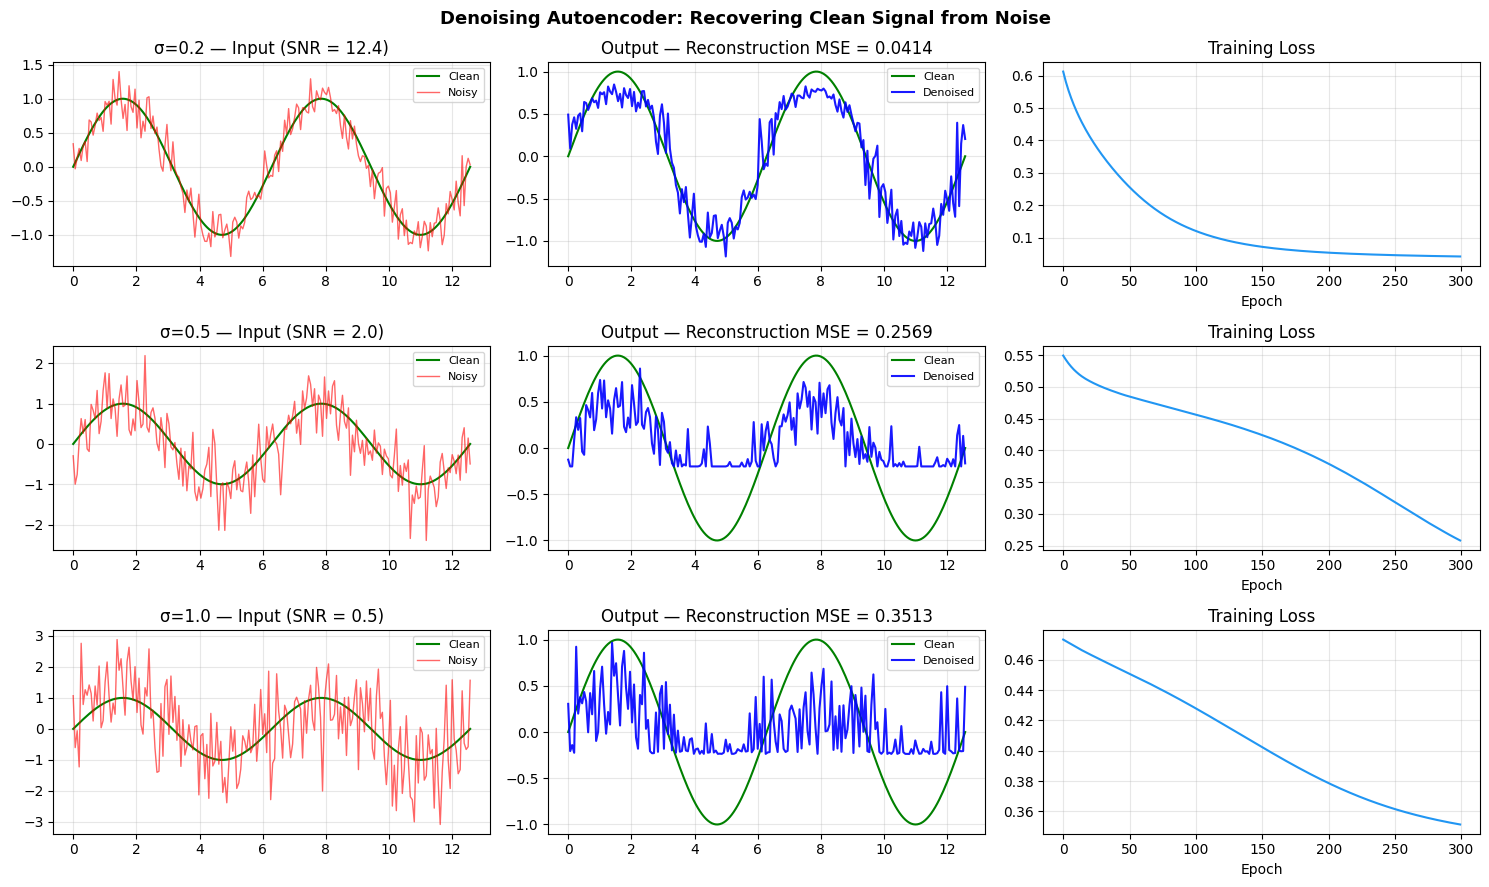

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── Denoising Autoencoder demonstration ───────────────────────────────────────
np.random.seed(7)

# Create a simple 1D signal (e.g., a sine wave) and add noise
t = np.linspace(0, 4*np.pi, 200)
signal = np.sin(t)                                     # clean signal
noise_levels = [0.2, 0.5, 1.0]

fig, axes = plt.subplots(len(noise_levels), 3, figsize=(15, 9))

def simple_ae_denoise(clean, noisy, lr=0.05, epochs=500):
    """Train a 1D denoising AE (1 → 8 → 4 → 8 → 1) on a single sample."""
    # Use each timestep as a separate feature for simplicity
    # Architecture: input → hidden → bottleneck → hidden → output
    W1 = np.random.randn(8, 1) * 0.5; b1 = np.zeros((8, 1))
    W2 = np.random.randn(4, 8) * 0.5; b2 = np.zeros((4, 1))
    W3 = np.random.randn(8, 4) * 0.5; b3 = np.zeros((8, 1))
    W4 = np.random.randn(1, 8) * 0.5; b4 = np.zeros((1, 1))
    
    losses = []
    for _ in range(epochs):
        # Forward (point-wise)
        x_in = noisy.reshape(1, -1)     # (1, 200)
        z1 = np.maximum(0, W1 @ x_in + b1)
        z2 = np.maximum(0, W2 @ z1    + b2)
        z3 = np.maximum(0, W3 @ z2    + b3)
        out = W4 @ z3 + b4              # (1, 200) — linear output

        target = clean.reshape(1, -1)
        loss = ((out - target)**2).mean()
        losses.append(loss)

        # Backward (simplified, single-pass)
        dout = 2*(out - target) / len(clean)
        dW4  = dout @ z3.T; db4 = dout.sum(axis=1, keepdims=True)
        dz3  = W4.T @ dout * (z3 > 0)
        dW3  = dz3 @ z2.T; db3 = dz3.sum(axis=1, keepdims=True)
        dz2  = W3.T @ dz3 * (z2 > 0)
        dW2  = dz2 @ z1.T; db2 = dz2.sum(axis=1, keepdims=True)
        dz1  = W2.T @ dz2 * (z1 > 0)
        dW1  = dz1 @ x_in.T; db1 = dz1.sum(axis=1, keepdims=True)

        for W, dW in [(W1,dW1),(W2,dW2),(W3,dW3),(W4,dW4)]:
            W -= lr * dW
        for b, db in [(b1,db1),(b2,db2),(b3,db3),(b4,db4)]:
            b -= lr * db

    # Final prediction
    z1 = np.maximum(0, W1 @ noisy.reshape(1,-1) + b1)
    z2 = np.maximum(0, W2 @ z1 + b2)
    z3 = np.maximum(0, W3 @ z2 + b3)
    return (W4 @ z3 + b4).squeeze(), losses

for row, sigma in enumerate(noise_levels):
    noisy = signal + np.random.randn(200) * sigma
    denoised, losses = simple_ae_denoise(signal, noisy, lr=0.01, epochs=300)

    axes[row, 0].plot(t, signal, "g-", linewidth=1.5, label="Clean")
    axes[row, 0].plot(t, noisy, "r-", alpha=0.6, linewidth=1, label="Noisy")
    axes[row, 0].set_title(f"σ={sigma} — Input (SNR = {signal.var()/sigma**2:.1f})")
    axes[row, 0].legend(fontsize=8); axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(t, signal, "g-", linewidth=1.5, label="Clean")
    axes[row, 1].plot(t, denoised, "b-", alpha=0.9, linewidth=1.5, label="Denoised")
    mse = ((signal - denoised)**2).mean()
    axes[row, 1].set_title(f"Output — Reconstruction MSE = {mse:.4f}")
    axes[row, 1].legend(fontsize=8); axes[row, 1].grid(alpha=0.3)

    axes[row, 2].plot(losses, color="#2196F3", linewidth=1.5)
    axes[row, 2].set_title("Training Loss"); axes[row, 2].grid(alpha=0.3)
    axes[row, 2].set_xlabel("Epoch")

plt.suptitle("Denoising Autoencoder: Recovering Clean Signal from Noise", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

---
## ✅ Course 2 Key Takeaways

**Transfer Learning:**
- Pre-trained models (ImageNet) provide powerful universal features
- Feature extraction (frozen) is best for small datasets; fine-tuning for larger ones
- Progressive unfreezing + differential LRs prevent catastrophic forgetting
- The closer the domains, the less fine-tuning needed

**Autoencoders:**
- Encoder-decoder architecture learns compressed representation via reconstruction loss
- Bottleneck forces meaningful feature learning — not just memorization
- Denoising AEs learn more robust features by reconstructing clean from noisy input
- Sparse/contractive AEs add penalties for interpretability and invariance
- Reconstruction error directly enables anomaly detection (high error = anomaly)

| Task | Best AE Type |
|------|-------------|
| Dimensionality reduction | Undercomplete |
| Anomaly detection | Undercomplete + recon error |
| Denoising | Denoising AE |
| Sparse representations | Sparse AE |
| Generation (smooth sampling) | VAE (Variational AE) |